In [1]:
import sys
sys.path.append('../src')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import time
import os

#noinspection PyUnresolvedReferences
from model_resnet_unet import ResNetUNet
#noinspection PyUnresolvedReferences
from dataset import get_dataloader

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Устройство: {device}")

Устройство: cpu


In [3]:
class Discriminator(nn.Module):
    """
    Отличает реальные цвета от сгенерированных
    Вход: цветное изображение 3×128×128
    Выход: вероятность (0 = фейк, 1 = реальное)
    """
    def __init__(self, in_channels=3):
        super().__init__()

        self.model = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Conv2d(128, 1, kernel_size=4, stride=1, padding=0),
            nn.AdaptiveAvgPool2d(1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1, 1)

In [4]:
criterion_gan = nn.BCELoss()  # Binary Cross Entropy (для дискриминатора)

def adversarial_loss(predictions, targets):
    """
    predictions: что предсказал дискриминатор
    targets: чего мы хотим (1 = реальное, 0 = фейк)
    """
    return criterion_gan(predictions, targets)

In [5]:
def show_prediction(epoch, save=False):
    generator.eval()
    with torch.no_grad():
        gray_batch, color_batch = next(iter(train_loader))
        gray_batch = gray_batch.to(device)
        pred_batch = generator(gray_batch)

        # Нормализация
        pred_img = pred_batch[0].cpu().permute(1, 2, 0).numpy()
        pred_img = (pred_img + 1) / 2
        pred_img = np.clip(pred_img, 0, 1)

        gray_img = gray_batch[0].cpu().squeeze().numpy()
        true_img = color_batch[0].permute(1, 2, 0).numpy()

        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(gray_img, cmap='gray')
        axes[0].set_title("Вход (ч/б)")
        axes[0].axis('off')

        axes[1].imshow(pred_img)
        axes[1].set_title(f"Предсказание (эпоха {epoch})")
        axes[1].axis('off')

        axes[2].imshow(true_img)
        axes[2].set_title("Реальное цветное")
        axes[2].axis('off')

        plt.tight_layout()

        if save:
            os.makedirs('results', exist_ok=True)
            plt.savefig(f'results/epoch_{epoch}.png', dpi=150)

        plt.show()

    generator.train()

In [6]:
data_dir = '../data/processed/test'
train_loader = get_dataloader(data_dir, batch_size=4, shuffle=True)

print(f"Загружено {len(train_loader.dataset)} изображений")
print(f"Батчей: {len(train_loader)}")

Загружено 2 изображений
Батчей: 1


In [7]:
LR_G = 1e-4
LR_D = 1e-4
LAMBDA_MSE = 10
LAMBDA_GAN = 0.5
D_TRAIN_FREQ = 2
NUM_EPOCHS = 30

generator = ResNetUNet(n_class=3).to(device)
discriminator = Discriminator(in_channels=3).to(device)

criterion_mse = nn.MSELoss()

optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(0.5, 0.999))

print(f"✅ Модели созданы")
print(f"   Генератор: {sum(p.numel() for p in generator.parameters()):,} параметров")
print(f"   Дискриминатор: {sum(p.numel() for p in discriminator.parameters()):,} параметров")

✅ Модели созданы
   Генератор: 18,311,787 параметров
   Дискриминатор: 168,033 параметров



🚀 НАЧИНАЕМ ОБУЧЕНИЕ (30 эпох)


✅ Эпоха 1/30 | G: 2.8733 | D: 0.7172 | MSE: 0.2495

✅ Эпоха 2/30 | G: 2.5645 | D: 0.6806 | MSE: 0.2167

✅ Эпоха 3/30 | G: 2.0329 | D: 0.6740 | MSE: 0.1641

✅ Эпоха 4/30 | G: 1.1592 | D: 0.6639 | MSE: 0.0751

✅ Эпоха 5/30 | G: 1.0817 | D: 0.6523 | MSE: 0.0658


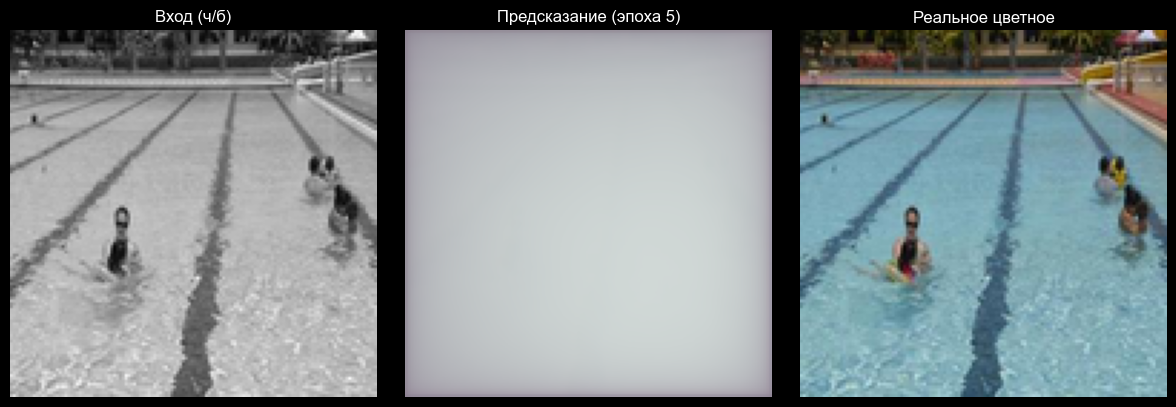


✅ Эпоха 6/30 | G: 0.8646 | D: 0.6433 | MSE: 0.0432

✅ Эпоха 7/30 | G: 0.8837 | D: 0.6331 | MSE: 0.0446

✅ Эпоха 8/30 | G: 0.8359 | D: 0.6118 | MSE: 0.0392

✅ Эпоха 9/30 | G: 0.8497 | D: 0.5946 | MSE: 0.0391

✅ Эпоха 10/30 | G: 0.8160 | D: 0.5861 | MSE: 0.0356


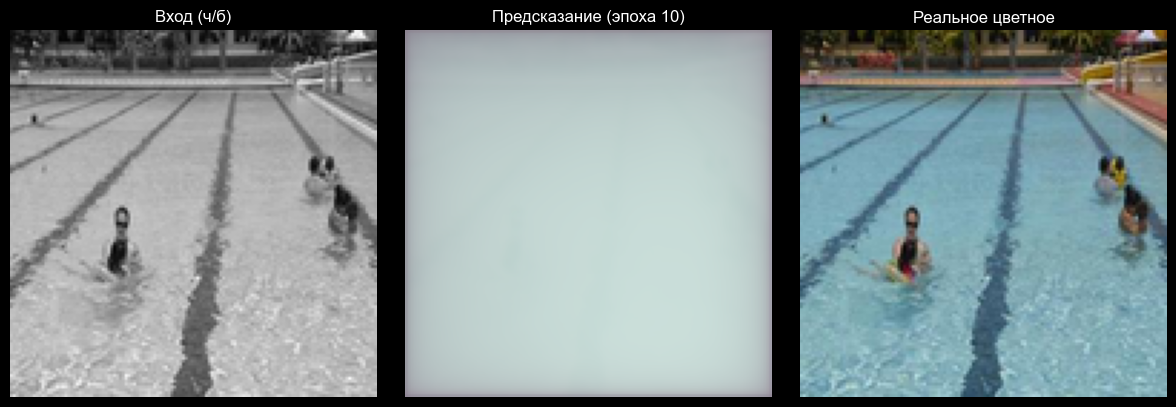

   💾 Чекпоинт сохранён (эпоха 10)

✅ Эпоха 11/30 | G: 0.8003 | D: 0.5776 | MSE: 0.0338

✅ Эпоха 12/30 | G: 0.7925 | D: 0.5681 | MSE: 0.0333

✅ Эпоха 13/30 | G: 0.7883 | D: 0.5653 | MSE: 0.0332

✅ Эпоха 14/30 | G: 0.7735 | D: 0.5550 | MSE: 0.0308

✅ Эпоха 15/30 | G: 0.7573 | D: 0.5580 | MSE: 0.0301


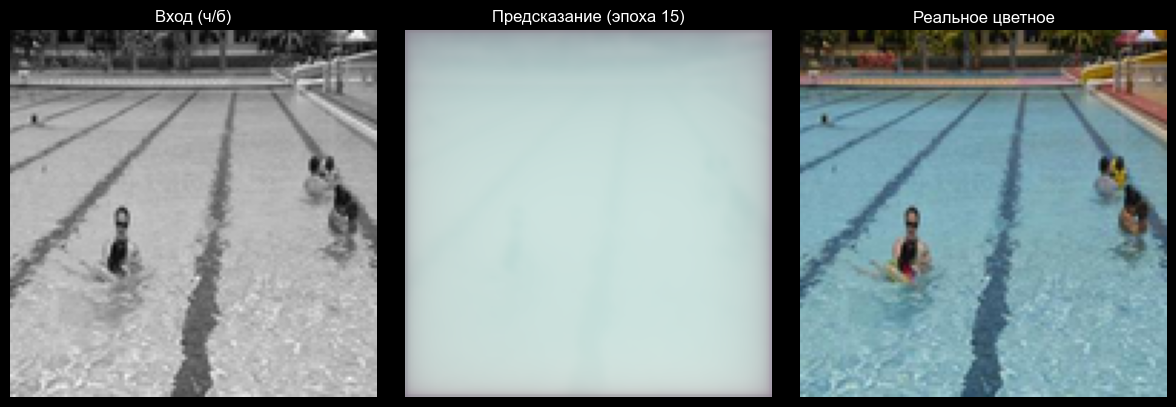


✅ Эпоха 16/30 | G: 0.7482 | D: 0.5539 | MSE: 0.0287

✅ Эпоха 17/30 | G: 0.7694 | D: 0.5702 | MSE: 0.0319

✅ Эпоха 18/30 | G: 0.7617 | D: 0.5604 | MSE: 0.0293

✅ Эпоха 19/30 | G: 0.7878 | D: 0.5824 | MSE: 0.0346

✅ Эпоха 20/30 | G: 0.7128 | D: 0.5660 | MSE: 0.0244


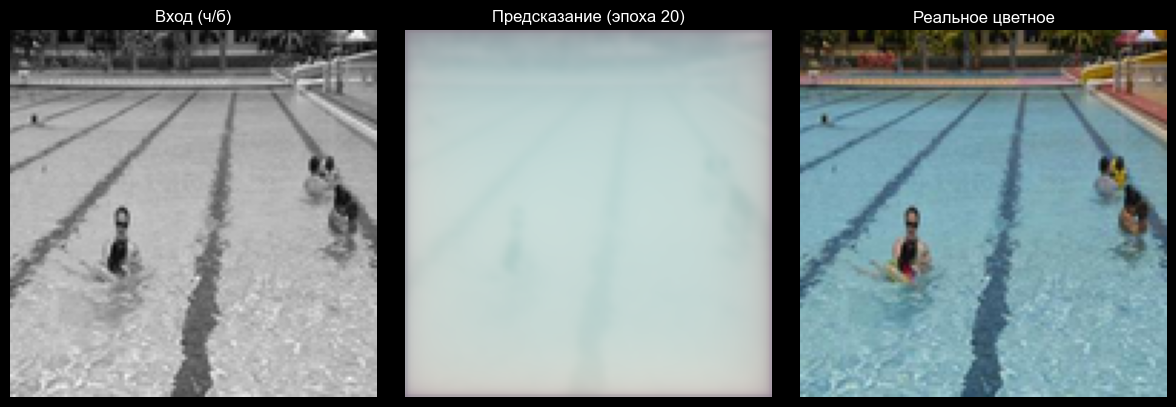

   💾 Чекпоинт сохранён (эпоха 20)

✅ Эпоха 21/30 | G: 0.7220 | D: 0.5525 | MSE: 0.0237

✅ Эпоха 22/30 | G: 0.7111 | D: 0.5557 | MSE: 0.0243

✅ Эпоха 23/30 | G: 0.6709 | D: 0.5472 | MSE: 0.0197

✅ Эпоха 24/30 | G: 0.6460 | D: 0.5509 | MSE: 0.0184

✅ Эпоха 25/30 | G: 0.6256 | D: 0.5528 | MSE: 0.0169


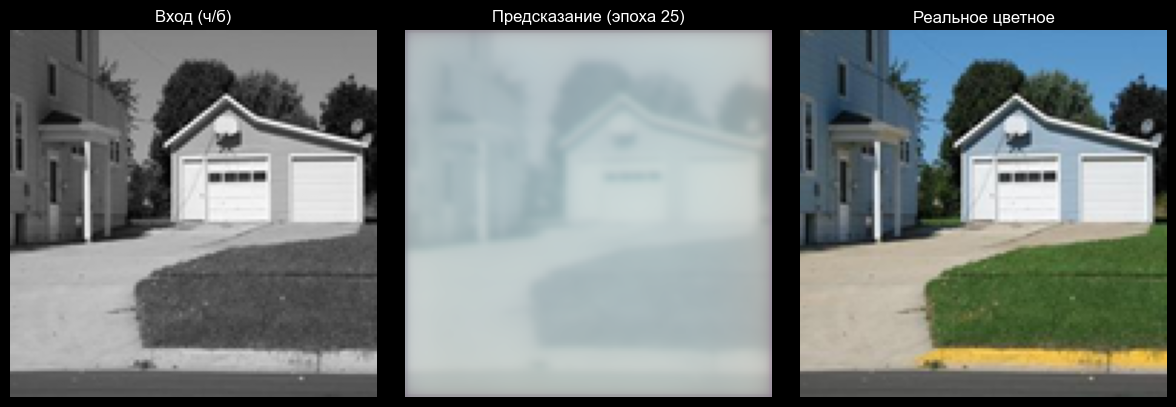


✅ Эпоха 26/30 | G: 0.6065 | D: 0.5600 | MSE: 0.0163

✅ Эпоха 27/30 | G: 0.5973 | D: 0.5586 | MSE: 0.0147

✅ Эпоха 28/30 | G: 0.6369 | D: 0.5785 | MSE: 0.0210

✅ Эпоха 29/30 | G: 0.7323 | D: 0.5439 | MSE: 0.0244

✅ Эпоха 30/30 | G: 0.7886 | D: 0.5868 | MSE: 0.0370


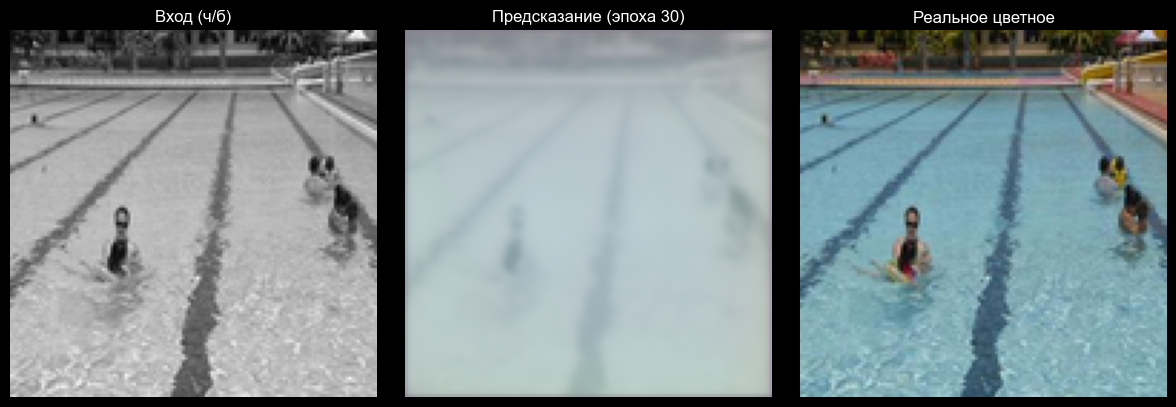

   💾 Чекпоинт сохранён (эпоха 30)


In [8]:
# Создаём папки для сохранения
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)

generator_losses = []
discriminator_losses = []
mse_losses = []

print("\n🚀 НАЧИНАЕМ ОБУЧЕНИЕ (30 эпох)\n")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_G = 0.0
    epoch_D = 0.0
    epoch_mse = 0.0
    n_batches = 0

    for batch_idx, (gray_batch, color_batch) in enumerate(train_loader):
        gray_batch = gray_batch.to(device)
        color_batch = color_batch.to(device)

        batch_size = color_batch.size(0)

        # Label smoothing
        real_labels = torch.ones(batch_size, 1).to(device) * 0.9
        fake_labels = torch.zeros(batch_size, 1).to(device) + 0.1

        # Шум
        noise = torch.randn_like(gray_batch) * 0.05
        gray_batch_noisy = gray_batch + noise

        # ===== DISCRIMINATOR =====
        loss_D = 0
        if batch_idx % D_TRAIN_FREQ == 0:
            optimizer_D.zero_grad()

            # Реальные изображения
            real_output = discriminator(color_batch)
            loss_real = adversarial_loss(real_output, real_labels)

            # Сгенерированные изображения
            with torch.no_grad():
                fake_batch = generator(gray_batch_noisy)
            fake_output = discriminator(fake_batch)
            loss_fake = adversarial_loss(fake_output, fake_labels)

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            optimizer_D.step()

        # ===== GENERATOR =====
        optimizer_G.zero_grad()

        fake_batch = generator(gray_batch_noisy)

        # Adversarial loss
        fake_output = discriminator(fake_batch)
        loss_G_adv = adversarial_loss(fake_output, real_labels)

        # MSE loss
        loss_G_mse = criterion_mse(fake_batch, color_batch)

        # Total loss
        loss_G = LAMBDA_MSE * loss_G_mse + LAMBDA_GAN * loss_G_adv
        loss_G.backward()
        optimizer_G.step()

        # Логирование
        epoch_G += loss_G.item()
        epoch_D += loss_D
        epoch_mse += loss_G_mse.item()
        n_batches += 1

        # Прогресс
        if (batch_idx + 1) % 200 == 0:
            print(f"[Эпоха {epoch+1}/{NUM_EPOCHS}] Батч {batch_idx+1}/{len(train_loader)} | G: {loss_G.item():.4f} | D: {loss_D:.4f}")

    # Сохраняем потери за эпоху
    avg_G = epoch_G / n_batches
    avg_D = epoch_D / n_batches
    avg_mse = epoch_mse / n_batches

    generator_losses.append(avg_G)
    discriminator_losses.append(avg_D)
    mse_losses.append(avg_mse)

    print(f"\n✅ Эпоха {epoch+1}/{NUM_EPOCHS} | G: {avg_G:.4f} | D: {avg_D:.4f} | MSE: {avg_mse:.4f}")

    # Визуализация каждые 5 эпох
    if (epoch + 1) % 5 == 0:
        show_prediction(epoch + 1, save=True)

    # Сохраняем чекпоинт каждые 10 эпох
    if (epoch + 1) % 10 == 0:
        torch.save({
            'epoch': epoch + 1,
            'generator_state_dict': generator.state_dict(),
            'discriminator_state_dict': discriminator.state_dict(),
            'optimizer_G_state_dict': optimizer_G.state_dict(),
            'optimizer_D_state_dict': optimizer_D.state_dict(),
            'loss_G': avg_G,
            'loss_D': avg_D,
        }, f'checkpoints/checkpoint_epoch_{epoch+1}.pth')
        print(f"   💾 Чекпоинт сохранён (эпоха {epoch+1})")

In [16]:
# Сохраняем финальную модель
os.makedirs('../models', exist_ok=True)
torch.save(generator.state_dict(), '../models/resnet_unet_gan.pth')
print(f"\n✅ Финальная модель сохранена: models/resnet_unet_gan.pth")

# Сохраняем историю потерь
history = {
    'generator_losses': generator_losses,
    'discriminator_losses': discriminator_losses,
    'mse_losses': mse_losses,
    'config': {
        'lr_G': LR_G,
        'lr_D': LR_D,
        'lambda_mse': LAMBDA_MSE,
        'lambda_gan': LAMBDA_GAN,
        'd_train_freq': D_TRAIN_FREQ,
        'num_epochs': NUM_EPOCHS
    }
}
torch.save(history, '../models/training_history.pth')


✅ Финальная модель сохранена: models/resnet_unet_gan.pth


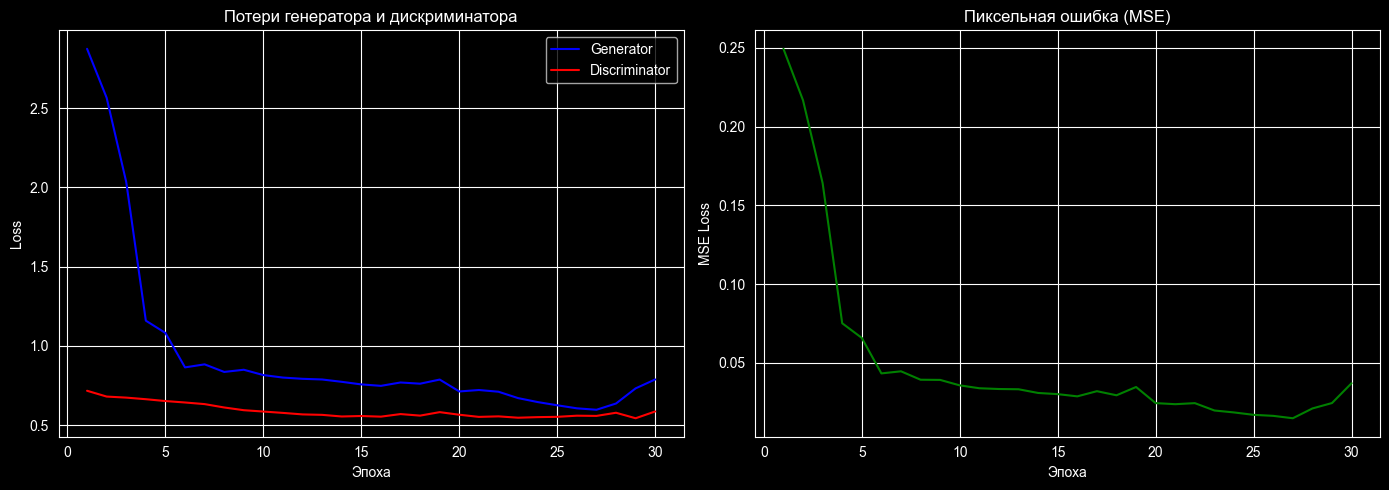

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График G и D потерь
gen_losses = [l.item() if torch.is_tensor(l) else l for l in generator_losses]
disc_losses = [l.item() if torch.is_tensor(l) else l for l in discriminator_losses]

axes[0].plot(range(1, NUM_EPOCHS + 1), gen_losses, 'b-', label='Generator')
axes[0].plot(range(1, NUM_EPOCHS + 1), disc_losses, 'r-', label='Discriminator')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Потери генератора и дискриминатора')
axes[0].legend()
axes[0].grid(True)

# График MSE потерь
axes[1].plot(range(1, NUM_EPOCHS + 1), mse_losses, 'g-')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('MSE Loss')
axes[1].set_title('Пиксельная ошибка (MSE)')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('results/loss_curves.png', dpi=150)
plt.show()



🎉 ОБУЧЕНИЕ ЗАВЕРШЕНО!
⏱️  Время обучения: 8.1 минут
📊 Финальная MSE: 0.0370
📊 Финальный G loss: 0.7886
📊 Финальный D loss: 0.5868


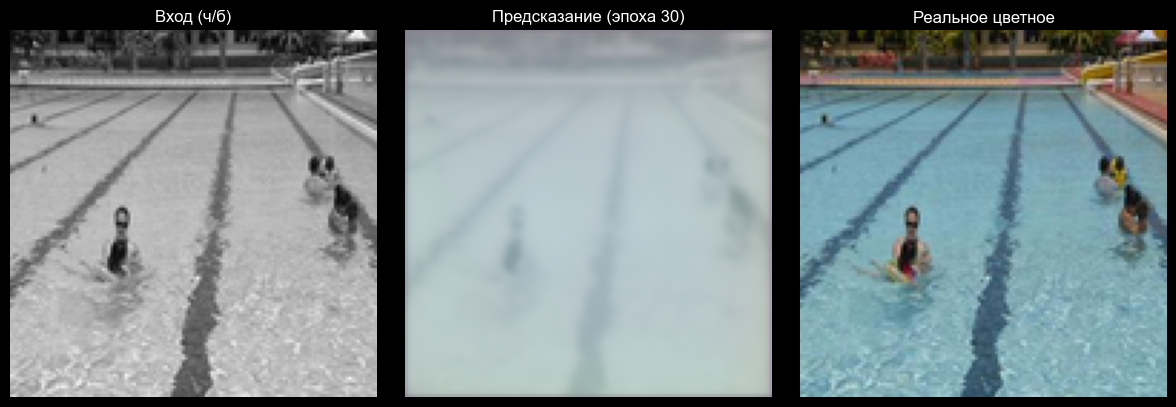


✅ Модель готова к использованию!


In [18]:
print("\n🎉 ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"⏱️  Время обучения: {(time.time() - start_time) / 60:.1f} минут")
print(f"📊 Финальная MSE: {mse_losses[-1]:.4f}")
print(f"📊 Финальный G loss: {generator_losses[-1]:.4f}")
print(f"📊 Финальный D loss: {discriminator_losses[-1]:.4f}")

# Покажем результат
show_prediction(NUM_EPOCHS, save=True)

print("\n✅ Модель готова к использованию!")